In [1]:
import os
os.chdir("../")
print(os.getcwd())

d:\git\ServerAnomalyDetection


In [2]:
import pandas as pd
from preprocessing.feature_engineer import build_model_input

df = pd.read_parquet("data/processed/server_metrics_20260503_20260504.parquet")
df = build_model_input(df)

In [3]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination='auto',
    random_state=42
)
X = df.copy()
clf.fit(X)

result_df = df.copy()
result_df["if_anomaly_score"] = -clf.decision_function(X)


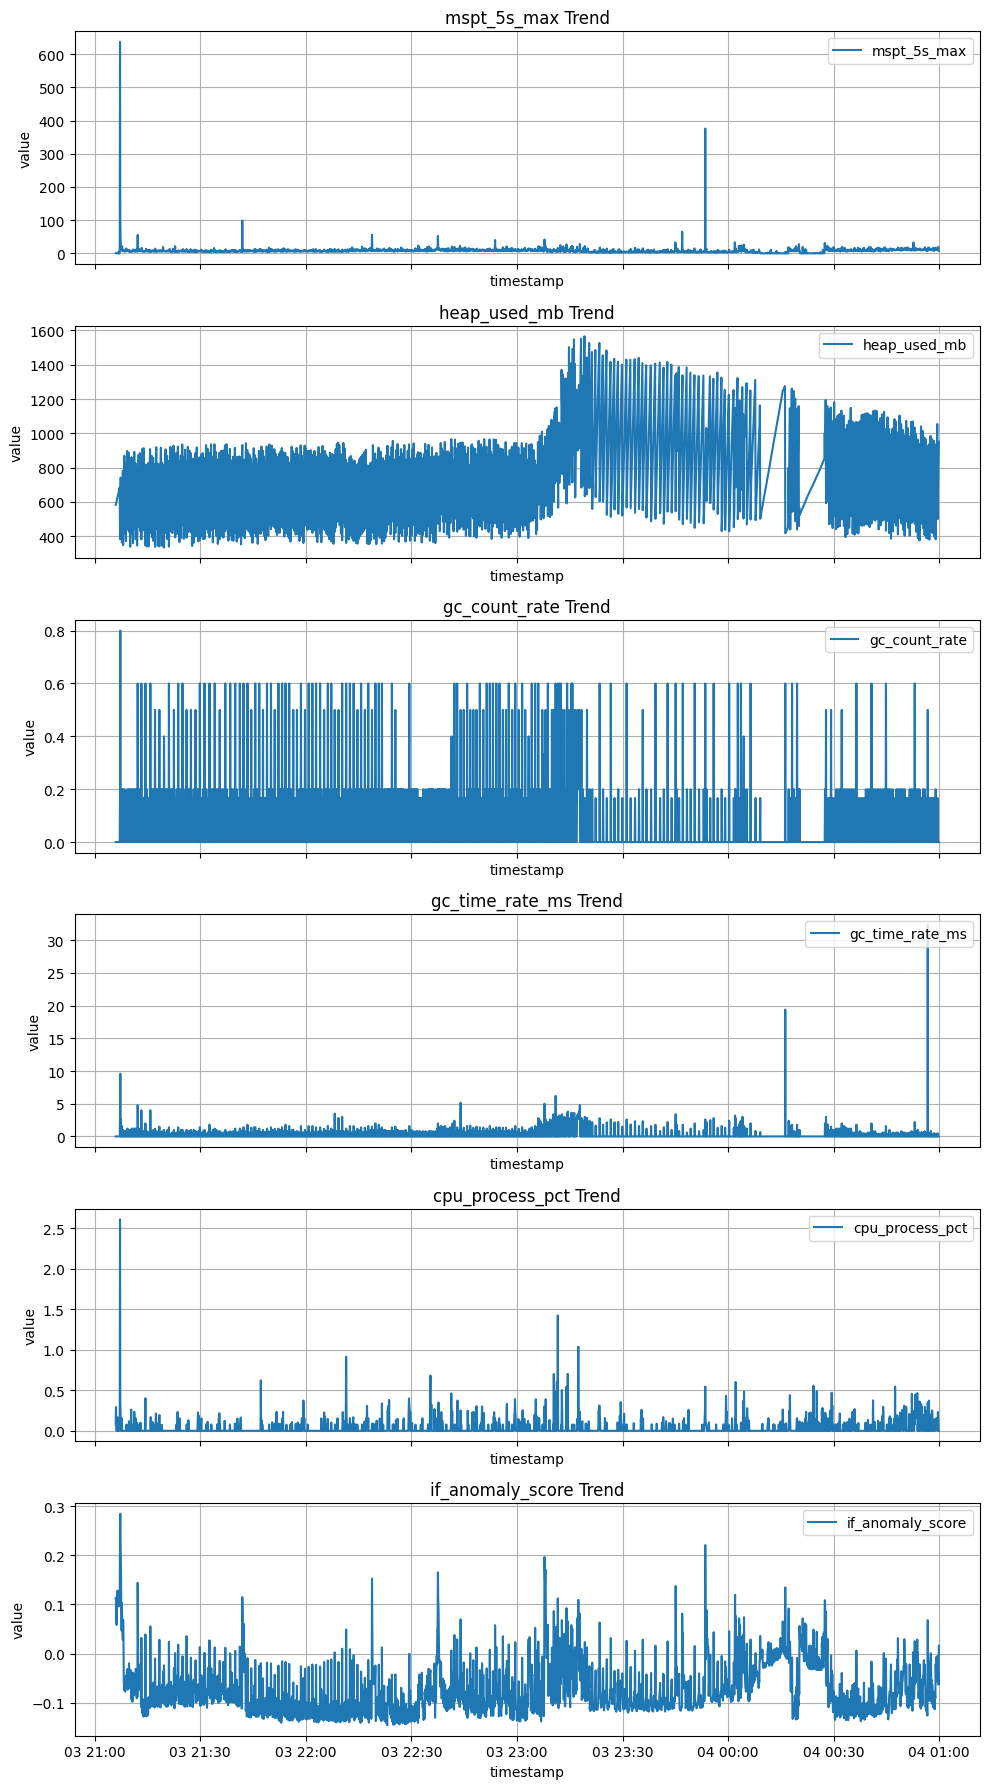

In [4]:
import matplotlib.pyplot as plt

columns = ["mspt_5s_max", "heap_used_mb", "gc_count_rate", "gc_time_rate_ms", "cpu_process_pct", "if_anomaly_score"]
fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(10, 3 * len(columns)), sharex=True)

for ax, column in zip(axes, columns):
    ax.plot(result_df.index, result_df[column], label=column)

    ax.set_title(f'{column} Trend')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('value')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.show()


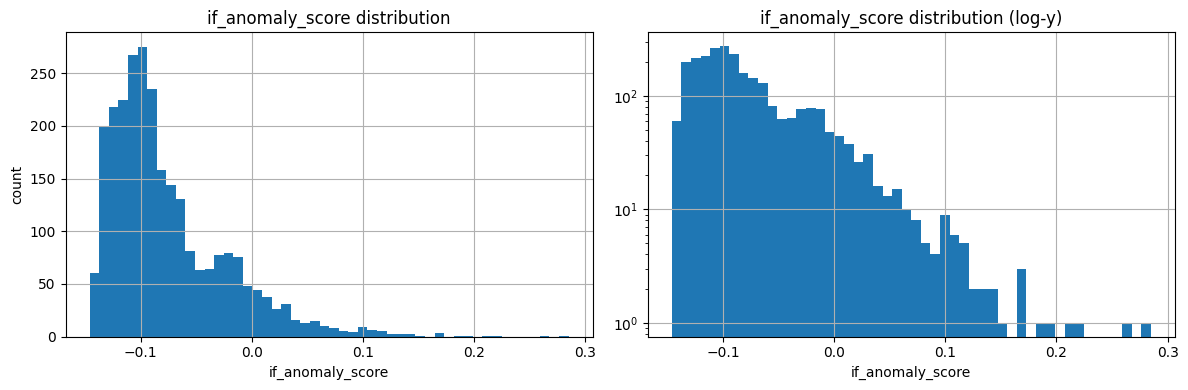

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(result_df["if_anomaly_score"], bins=50)
axes[0].set_title("if_anomaly_score distribution")
axes[0].set_xlabel("if_anomaly_score")
axes[0].set_ylabel("count")
axes[0].grid(True)

axes[1].hist(result_df["if_anomaly_score"], bins=50, log=True)
axes[1].set_title("if_anomaly_score distribution (log-y)")
axes[1].set_xlabel("if_anomaly_score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
for th in [0.0, 0.05, 0.1, 0.15, 0.2]:
    print(f"score > {th}: {(result_df['if_anomaly_score'] > th).sum()} 件")

score > 0.0: 251 件
score > 0.05: 82 件
score > 0.1: 31 件
score > 0.15: 10 件
score > 0.2: 4 件


In [7]:
cols_to_check = [
    "mspt_5s_max", "mspt_10s_max", "mspt_1m_max",
    "mspt_5s_avg", "heap_used_mb",
    "cpu_process_pct", "gc_count_rate", "gc_time_rate_ms", "thread_count",
    "if_anomaly_score",
]
top_anomalies = result_df[result_df["if_anomaly_score"] > 0.1].sort_values("if_anomaly_score", ascending=False)
top_anomalies[cols_to_check]

,mspt_5s_max,mspt_10s_max,mspt_1m_max,mspt_5s_avg,heap_used_mb,cpu_process_pct,gc_count_rate,gc_time_rate_ms,thread_count,if_anomaly_score
timestamp,,,,,,,,,,
2026-05-03 21:07:16,98.1,636.7,636.7,16.7,533.443665,0.340772,0.800000,9.600000,64,0.284885
2026-05-03 21:07:11,636.7,636.7,636.7,15.9,382.615196,2.611649,0.200000,3.000000,63,0.262848
2026-05-03 23:53:31,375.7,375.7,375.7,10.5,674.919113,0.546167,0.600000,2.600000,63,0.220845
2026-05-03 21:07:22,31.6,98.1,636.7,9.5,741.443665,0.153500,0.000000,0.000000,63,0.209802
2026-05-03 23:07:49,42.0,42.0,42.0,9.8,606.911041,0.302708,0.333333,5.000000,66,0.196411
2026-05-03 21:07:27,22.9,31.6,636.7,7.7,408.274185,0.000000,0.200000,2.600000,63,0.182863
2026-05-03 23:08:05,24.3,24.3,42.0,8.6,737.895805,0.000000,0.500000,2.666667,65,0.171193
2026-05-03 23:07:54,28.5,30.5,42.0,10.1,572.552536,0.156218,0.200000,3.000000,65,0.168310
2026-05-03 22:37:32,52.7,52.7,52.7,7.9,472.272194,0.000000,0.200000,2.000000,63,0.165192


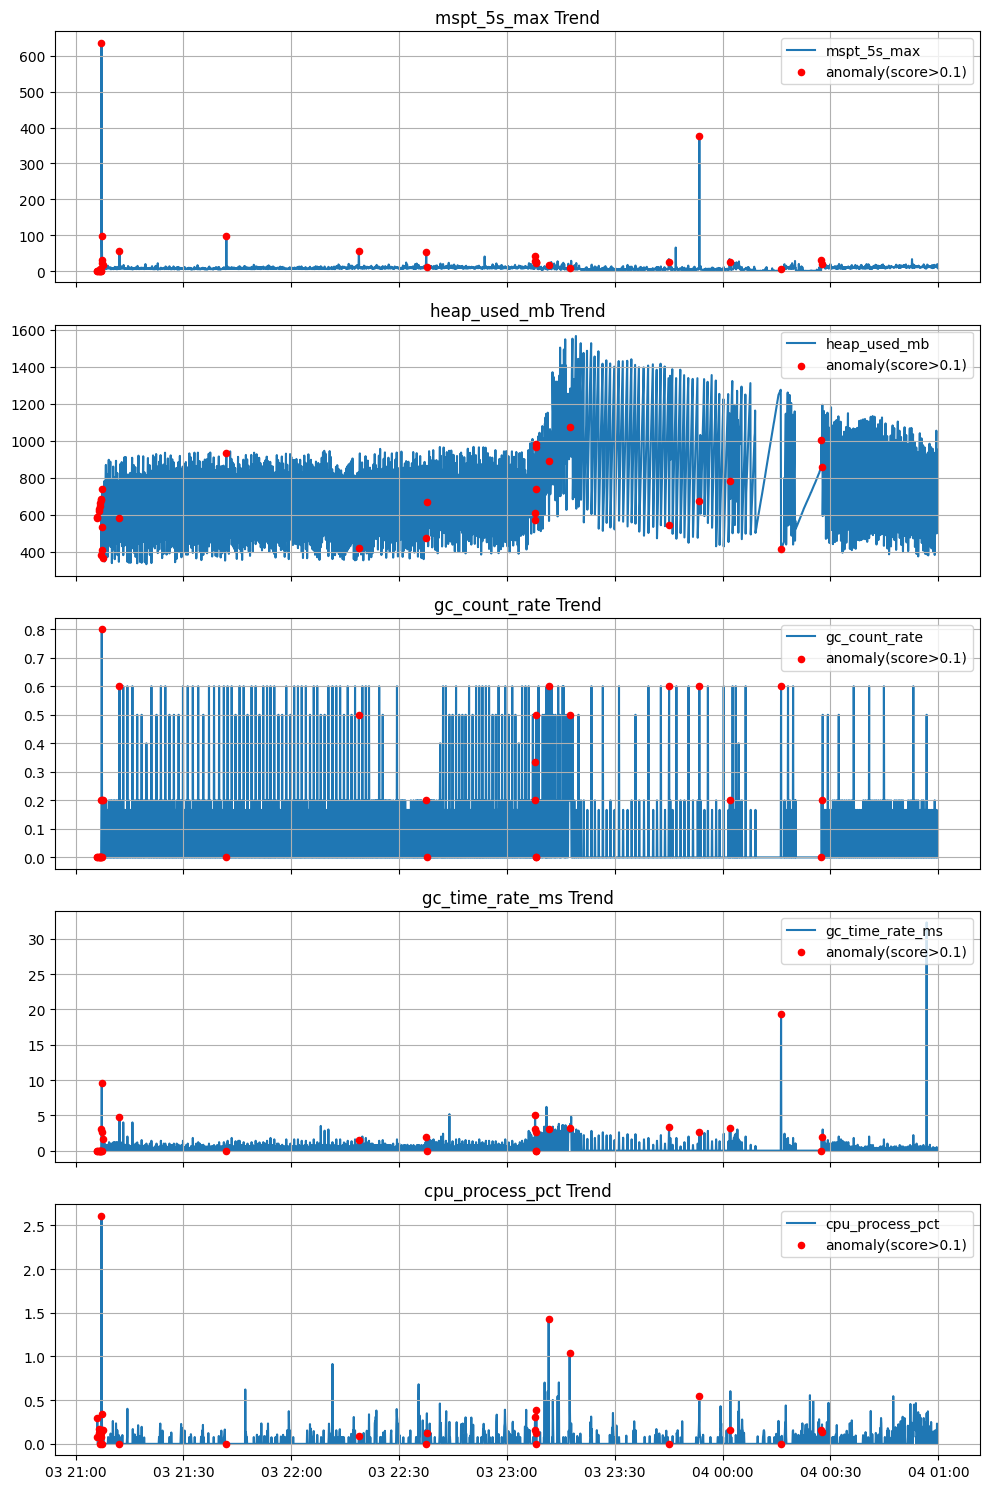

In [8]:
import matplotlib.pyplot as plt

anomaly_idx = result_df[result_df["if_anomaly_score"] > 0.1].index

columns = ["mspt_5s_max", "heap_used_mb", "gc_count_rate", "gc_time_rate_ms", "cpu_process_pct"]
fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(10, 3 * len(columns)), sharex=True)

for ax, column in zip(axes, columns):
    ax.plot(result_df.index, result_df[column], label=column, zorder=1)
    ax.scatter(anomaly_idx, result_df.loc[anomaly_idx, column], color="red", s=20, zorder=2, label="anomaly(score>0.1)")
    ax.set_title(f"{column} Trend")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [9]:
result_df.sort_values("gc_time_rate_ms", ascending=False).head(5)[
    ["mspt_5s_max","heap_used_mb","cpu_process_pct","gc_count_rate","gc_time_rate_ms","if_anomaly_score"]
]

,mspt_5s_max,heap_used_mb,cpu_process_pct,gc_count_rate,gc_time_rate_ms,if_anomaly_score
timestamp,,,,,,
2026-05-04 00:56:45,14.0,385.596481,0.350500,0.5,32.333333,0.067952
2026-05-04 00:16:15,4.9,416.247498,0.000000,0.6,19.400000,0.134669
2026-05-03 21:07:16,98.1,533.443665,0.340772,0.8,9.600000,0.284885
2026-05-03 23:10:59,7.7,933.000000,0.000000,0.6,6.200000,0.054386
2026-05-03 22:43:59,15.5,531.575195,0.251880,0.5,5.166667,0.069526


In [10]:
result_df.sort_values("gc_time_rate_ms", ascending=False).head(15)[
    ["mspt_5s_max","heap_used_mb","cpu_process_pct","gc_count_rate","gc_time_rate_ms","if_anomaly_score"]
]

,mspt_5s_max,heap_used_mb,cpu_process_pct,gc_count_rate,gc_time_rate_ms,if_anomaly_score
timestamp,,,,,,
2026-05-04 00:56:45,14.0,385.596481,0.350500,0.500000,32.333333,0.067952
2026-05-04 00:16:15,4.9,416.247498,0.000000,0.600000,19.400000,0.134669
2026-05-03 21:07:16,98.1,533.443665,0.340772,0.800000,9.600000,0.284885
2026-05-03 23:10:59,7.7,933.000000,0.000000,0.600000,6.200000,0.054386
2026-05-03 22:43:59,15.5,531.575195,0.251880,0.500000,5.166667,0.069526
2026-05-03 23:07:49,42.0,606.911041,0.302708,0.333333,5.000000,0.196411
2026-05-03 21:12:12,55.8,584.192963,0.000000,0.600000,4.800000,0.144080
2026-05-03 23:17:52,28.5,913.557808,0.234146,0.200000,4.800000,0.081611
2026-05-03 21:15:48,8.6,418.431221,0.000000,0.600000,4.000000,0.055315
